In [2]:
from cirq_sic import *

d = 2
base_dir = "data/sky_ground"
wh_implementation = "simple"

psi_stab = np.eye(d)[0]
psi_sic = load_sic_fiducial(d)
interpolation = geodesic_interpolator(psi_stab, psi_sic)

T = np.linspace(0, 1, 100) # 13.152
task_t = {t: CharacterizeWHReferenceDeviceTask(\
             **{"dataset_id": "1param",
               "processor_id": "willow_pink",
               "run_type": "clean",
               "qubits": get_wh_qubits(d, wh_implementation),
               "n_shots": 100000,
               "optimizer": "cirq",
               "d": d,
               "fiducial": interpolation(t),
               "fiducial_description": f"interpolation_{np.round(t, 4)}",
               "wh_implementation": wh_implementation}) for t in T}

for t, task in task_t.items():
    run_sky_ground_task(task, base_dir=base_dir)

2026-03-18 22:50:06 [INFO] 1param/d2/CharacterizeWHReferenceDeviceTask/simple/interpolation_0.0/cirq_clean_n100k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2026-03-18 22:50:06 [INFO] 1param/d2/CharacterizeWHReferenceDeviceTask/simple/interpolation_0.0101/cirq_clean_n100k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2026-03-18 22:50:06 [INFO] 1param/d2/CharacterizeWHReferenceDeviceTask/simple/interpolation_0.0202/cirq_clean_n100k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2026-03-18 22:50:06 [INFO] 1param/d2/CharacterizeWHReferenceDeviceTask/simple/interpolation_0.0303/cirq_clean_n100k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2026-03-18 22:50:06 [INFO] 1param/d2/CharacterizeWHReferenceDeviceTask/simple/interpolation_0.0404/cirq_clean_n100k_willow_pink_q4_2-5_2: Task already exists. Skipping.
2026-03-18 22:50:06 [INFO] 1param/d2/CharacterizeWHReferenceDeviceTask/simple/interpolation_0.0505/cirq_clean_n100k_willow_pink_q4_2-5_2: Task already exists.

In [3]:
interpolation(0), psi_stab

(array([1.+0.j, 0.+0.j]), array([1., 0.]))

In [4]:
interpolation(1)/interpolation(1)[0], psi_sic/psi_sic[0]

(array([1.   +0.j   , 0.366-0.366j]), array([1.   +0.j   , 0.366-0.366j]))

In [5]:
alpha = 2

magic_t = []
quantumness_t = []
for t, task in task_t.items():
    results = load_results(task)
    P = np.array(results["processed_data"]["P"])
    magic = (1/(1-alpha))*np.log(np.sum(P[:,0]**alpha)) - np.log(d)
    magic_t.append(magic)
    quantumness_t.append(np.linalg.norm(np.linalg.pinv(P) - np.eye(d**2)))

magic_t = np.array(magic_t)
quantumness_t = np.array(quantumness_t)
max_magic = (1/(1-alpha))*np.log((1+(d-1)*(d+1)**(1-alpha))/d)
sic_quantumness = np.linalg.norm(np.eye(d**2) - np.linalg.inv(SIC_P(d)))

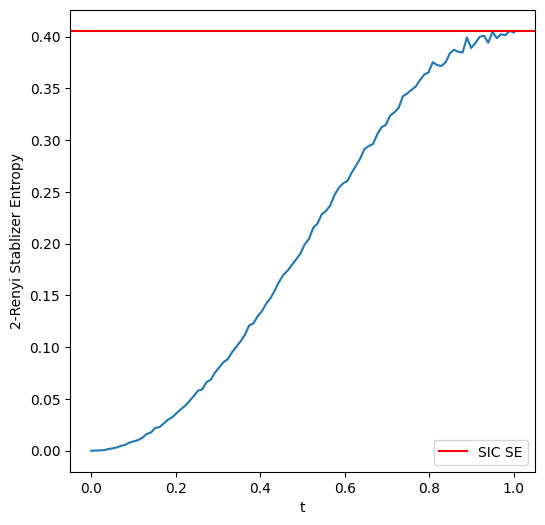

In [6]:
fig, ax = plt.subplots(1, figsize=(6,6))
ax.plot(T, magic_t)
ax.axhline(y=max_magic, label="SIC SE", color="red")
ax.set_xlabel("t")
ax.set_ylabel("%d-Renyi Stablizer Entropy" % alpha)
ax.legend()
fig.savefig("img/%drenyi_se.pdf" % alpha)

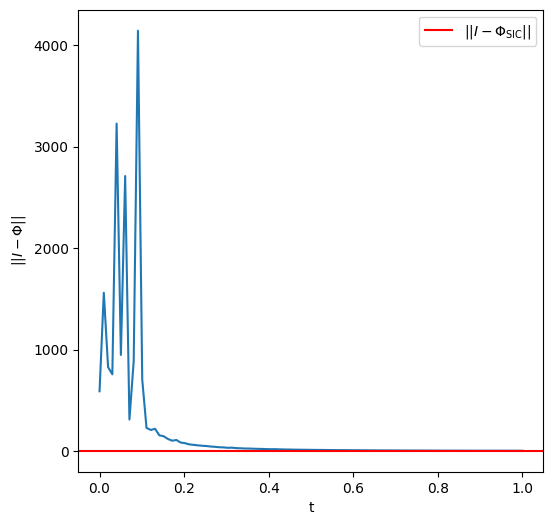

In [74]:
fig, ax = plt.subplots(1, figsize=(6,6))
ax.plot(T, quantumness_t)
ax.axhline(y=np.linalg.norm(np.eye(d**2) - np.linalg.inv(SIC_P(d))), label=r"$|| I - \Phi_{\text{SIC}} ||$", color="red")
ax.set_xlabel("t")
ax.set_ylabel(r"$|| I - \Phi ||$")
ax.legend()
fig.savefig("img/quantumness.pdf")

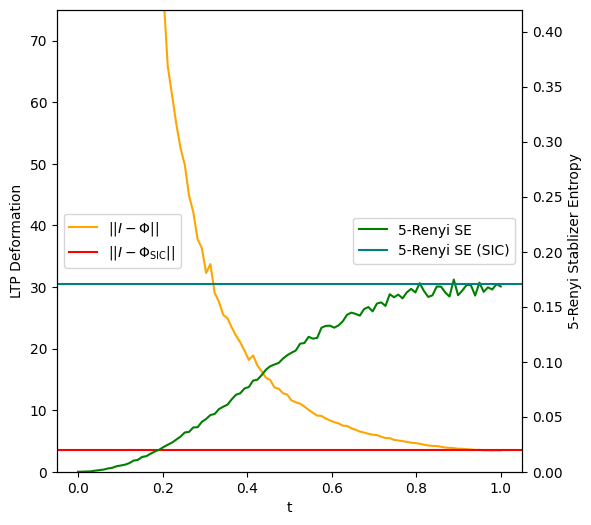

In [75]:
log = False
fig, ax = plt.subplots(1, figsize=(6,6))
if not log:
    ax.plot(T, quantumness_t, label=r"$|| I - \Phi ||$", color="orange")
    ax.axhline(y=sic_quantumness, label=r"$|| I - \Phi_{\text{SIC}} ||$", color="red")
    ax.set_ylabel(r"LTP Deformation")
    ax.set_ylim(0, 75)
else:
    ax.plot(T, np.log(quantumness_t), label=r"$|| I - \Phi ||$", color="orange")
    ax.axhline(y=np.log(sic_quantumness), label=r"$|| I - \Phi_{\text{SIC}} ||$", color="red")
    ax.set_ylabel(r"log LTP Deformation")  
    ax.set_ylim(0, 8)
ax.legend(loc='center left')

ax.set_xlabel("t")
ax.legend(loc='center left')

ax2 = ax.twinx()
ax2.plot(T, magic_t, color="green", label="%d-Renyi SE" % alpha)
ax2.axhline(y=max_magic, label=r"%d-Renyi SE (SIC)" % alpha, color="teal")
ax2.set_xlabel("t")
ax2.set_ylabel("%d-Renyi Stablizer Entropy" % alpha)
ax2.legend(loc='center right')
ax2.set_ylim(0, 0.42)
fig.savefig("img/%sboth_order%d.pdf" % ("log" if log else "", alpha))

In [8]:
alphas = [2,3,4,5]

magic_t = []
quantumness_t = []
for t, task in task_t.items():
    results = load_results(task)
    P = np.array(results["processed_data"]["P"])
    magics = {}
    for alpha in alphas:
        magic = (1/(1-alpha))*np.log(np.sum(P[:,0]**alpha)) - np.log(d)
        magics[alpha] = magic
    magic_t.append(magics)
    quantumness_t.append(np.linalg.norm(np.linalg.pinv(P) - np.eye(d**2)))

max_magics = [(1/(1-alpha))*np.log((1+(d-1)*(d+1)**(1-alpha))/d) for alpha in alphas]
quantumness_t = np.array(quantumness_t)
sic_quantumness = np.linalg.norm(np.eye(d**2) - np.linalg.inv(SIC_P(d)))


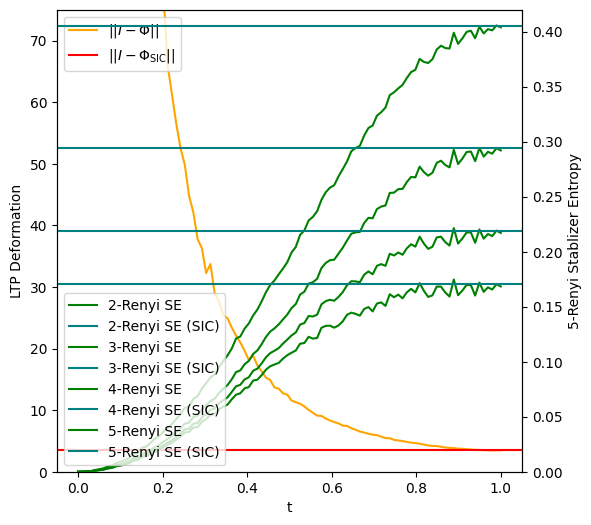

In [21]:
log = False
fig, ax = plt.subplots(1, figsize=(6,6))
ax.plot(T, quantumness_t, label=r"$|| I - \Phi ||$", color="orange")
ax.axhline(y=sic_quantumness, label=r"$|| I - \Phi_{\text{SIC}} ||$", color="red")
ax.set_ylabel(r"LTP Deformation")
ax.set_ylim(0, 75)

ax.legend(loc='upper left')

ax.set_xlabel("t")

ax2 = ax.twinx()
for i, alpha in enumerate(alphas):
    ax2.plot(T, [m[alpha] for m in magic_t], color="green", label="%d-Renyi SE" % alpha)
    ax2.axhline(y=max_magics[i], label=r"%d-Renyi SE (SIC)" % alpha, color="teal")
ax2.set_xlabel("t")
ax2.set_ylabel("%d-Renyi Stablizer Entropy" % alpha)
ax2.legend(loc='lower left')
ax2.set_ylim(0, 0.42)
fig.savefig("img/%sboth_order%d.pdf" % ("log" if log else "", alpha))